<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [37]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split
import pickle

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Embedding
)

In [3]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

Downloading...
From: https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN
To: /content/data_volunteers.json
100%|██████████| 2.58M/2.58M [00:00<00:00, 126MB/s]


In [4]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [5]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [6]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 30

def clean_text(txt):
    txt = txt.lower()
    txt = txt.replace("\'d", " had")
    txt = txt.replace("\'s", " is")
    txt = txt.replace("\'m", " am")
    txt = txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt.strip()

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 6274


In [7]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you', 'not bad and you <eos>', '<sos> not bad and you')

### ***Pueden realizar el desafio en Keras o PyTorch.***

### Preparación inicial del dataset

A partir del notebook base provisto, se realizó la descarga y carga del dataset de conversaciones.

Posteriormente se aplicó un preprocesamiento inicial sobre los diálogos:
- limpieza básica del texto,
- separación de pares pregunta–respuesta,
- incorporación de tokens especiales `<sos>` y `<eos>` para el decoder.

Estas estructuras serán utilizadas en la etapa de tokenización y preparación de secuencias.

# DESARROLLO

# 2 - Preprocesamiento

Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

---

## Tokenización de las secuencias de entrada

En primer lugar se construyó un vocabulario para las oraciones de entrada del encoder.

La tokenización permite asignar un índice entero a cada palabra presente en el corpus y transformar cada oración en una secuencia numérica.

Estas secuencias serán posteriormente utilizadas como entrada del modelo LSTM encoder.

### Tokenizador Encoder

In [8]:
tokenizer_inputs = Tokenizer()
tokenizer_inputs.fit_on_texts(input_sentences)

encoder_input_sequences = tokenizer_inputs.texts_to_sequences(input_sentences)

word2idx_inputs = tokenizer_inputs.word_index

print('Cantidad de palabras únicas de entrada:', len(word2idx_inputs))

Cantidad de palabras únicas de entrada: 1877


## Longitud máxima de entrada

Se calculó la longitud máxima de las secuencias de entrada para poder unificar posteriormente las dimensiones mediante padding.

In [9]:
max_input_len = max(len(s) for s in encoder_input_sequences)

print("Longitud máxima input:", max_input_len)

Longitud máxima input: 9


## Tokenización de las secuencias de salida

Se realizó el mismo procedimiento para las secuencias utilizadas por el decoder.

En este caso se conservaron explícitamente los tokens especiales `<sos>` y `<eos>`, necesarios para implementar el mecanismo de entrenamiento Seq2Seq.

### Tokenizador Decoder:

In [10]:
tokenizer_outputs = Tokenizer(filters='')
tokenizer_outputs.fit_on_texts(output_sentences + output_sentences_inputs)

decoder_output_sequences = tokenizer_outputs.texts_to_sequences(output_sentences_inputs)

decoder_targets = tokenizer_outputs.texts_to_sequences(output_sentences)

word2idx_outputs = tokenizer_outputs.word_index

print('Cantidad de palabras únicas de salida:', len(word2idx_outputs))

Cantidad de palabras únicas de salida: 1866


## Longitud máxima de salida

Se obtuvo la longitud máxima de las secuencias de salida del decoder para definir posteriormente el tamaño uniforme de las secuencias.

In [11]:
max_out_len = max(len(s) for s in decoder_targets)

print("Longitud máxima output:", max_out_len)

Longitud máxima output: 10


## Tamaño del vocabulario de salida

Se calculó la cantidad total de palabras únicas presentes en las secuencias de salida.

Este valor será utilizado posteriormente para definir la dimensión de la capa de salida del modelo.

In [12]:
num_words_output = len(word2idx_outputs) + 1

print("Cantidad total palabras output:", num_words_output)

Cantidad total palabras output: 1867


## Padding de secuencias

Las secuencias obtenidas poseen longitudes variables.

Para poder procesarlas correctamente, se aplicó padding agregando ceros al final de cada secuencia hasta alcanzar una longitud uniforme.

In [13]:
encoder_inputs = pad_sequences(
    encoder_input_sequences,
    maxlen=max_input_len,
    padding='post'
)

print("Shape encoder inputs:", encoder_inputs.shape)

Shape encoder inputs: (6274, 9)


In [14]:
decoder_inputs = pad_sequences(
    decoder_output_sequences,
    maxlen=max_out_len,
    padding='post'
)

print("Shape decoder inputs:", decoder_inputs.shape)

Shape decoder inputs: (6274, 10)


In [15]:
decoder_targets = pad_sequences(
    decoder_targets,
    maxlen=max_out_len,
    padding='post'
)

print("Shape decoder targets:", decoder_targets.shape)

Shape decoder targets: (6274, 10)


## Resultado del preprocesamiento

Se obtuvieron las estructuras necesarias para entrenar el modelo encoder–decoder:

- vocabularios de entrada y salida,
- secuencias tokenizadas,
- longitudes máximas,
- secuencias con padding uniforme.

Estas estructuras serán utilizadas en la etapa de construcción y entrenamiento del modelo Seq2Seq basado en LSTM.

# 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

## Embeddings preentrenados

Para representar las palabras mediante vectores densos,en este trabajo se utilizaron embeddings GloVe de 100 dimensiones.

In [16]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-05-07 18:37:57--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-07 18:37:57--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-07 18:37:57--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

## Carga de embeddings GloVe

A continuación se cargan los embeddings preentrenados GloVe.

In [17]:
# Cargar embeddings GloVe
word2vec = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()

        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')

        word2vec[word] = vector

print('Cantidad de vectores cargados:', len(word2vec))

Cantidad de vectores cargados: 400000


## Construcción de la matriz de embeddings

Se construyó una matriz de embeddings utilizando el vocabulario obtenido durante la tokenización.

Cada fila de la matriz contiene el vector GloVe asociado a una palabra del vocabulario de entrada.

Las palabras que no se encontraron en los embeddings preentrenados permanecen inicializadas en cero.

In [18]:
# Construcción de embedding matrix
num_words_input = len(word2idx_inputs) + 1
embedding_dim = 100

embedding_matrix = np.zeros((num_words_input, embedding_dim))

for word, idx in word2idx_inputs.items():

    if idx < num_words_input:

        embedding_vector = word2vec.get(word)

        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector

print("Shape embedding matrix:", embedding_matrix.shape)

Shape embedding matrix: (1878, 100)


## Resultado

Se obtuvo una matriz de embeddings de dimensión `(1878, 100)` utilizando vectores preentrenados GloVe.

Esta matriz permitirá representar cada token del vocabulario mediante un vector denso de 100 dimensiones, incorporando información semántica previamente aprendida.

La matriz de embeddings será utilizada posteriormente en la capa `Embedding` del encoder del modelo Seq2Seq.

---

# 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

## Modelo Seq2Seq basado en encoder–decoder

Se implementó un modelo Seq2Seq utilizando una arquitectura encoder–decoder basada en redes LSTM.

El encoder procesa la secuencia de entrada y genera un estado interno que resume la información contextual de la oración.

Posteriormente, el decoder utiliza dicho estado para generar la secuencia de salida palabra por palabra.

Además, la capa de embedding del encoder utiliza los vectores GloVe previamente calculados.

In [19]:
# Hiperparámetros
latent_dim = 256
embedding_dim = 100

In [21]:
# Encoder
encoder_inputs_placeholder = Input(shape=(max_input_len,))

encoder_embedding = Embedding(
    input_dim=num_words_input,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)

x = encoder_embedding(encoder_inputs_placeholder)

encoder = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, h, c = encoder(x)

encoder_states = [h, c]

## Construcción del decoder

El decoder recibe como estado inicial los estados generados por el encoder.

Durante el entrenamiento, el decoder utiliza las secuencias objetivo desplazadas mediante la técnica de *teacher forcing* para aprender a predecir la siguiente palabra de la respuesta.

In [22]:
# Decoder
decoder_inputs_placeholder = Input(shape=(max_out_len,))

decoder_embedding = Embedding(
    input_dim=num_words_output,
    output_dim=latent_dim
)

decoder_inputs_x = decoder_embedding(decoder_inputs_placeholder)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs_x,
    initial_state=encoder_states
)

decoder_dense = Dense(
    num_words_output,
    activation='softmax'
)

decoder_outputs = decoder_dense(decoder_outputs)

## Construcción y entrenamiento del modelo

Se conectaron el encoder y el decoder para formar el modelo Seq2Seq completo.

El entrenamiento se realizó utilizando las secuencias de entrada del encoder, las secuencias desplazadas del decoder y las salidas esperadas correspondientes.

> Nota: inicialmente se evaluó utilizar codificación one-hot para las salidas del decoder.  
> Sin embargo, posteriormente se utilizó la función de pérdida `sparse_categorical_crossentropy`, la cual permite trabajar directamente con índices enteros, reduciendo significativamente el consumo de memoria.

In [23]:
# Modelo completo
model = Model(
    [encoder_inputs_placeholder, decoder_inputs_placeholder],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 9, 100)    │    187,800 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 10, 256)   │    477,952 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 256),     │    365,568 │ embedding_1[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 10, 256), │    525,312 │ embedding_2[0][0… │
│                     │ (None, 256),      │            │ lstm_1[0][1],     │
│                     │ (None, 256)]      │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 1867)  │    479,819 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,036,451 (7.77 MB)

 Trainable params: 1,848,651 (7.05 MB)

 Non-trainable params: 187,800 (733.59 KB)

## Parámetros de entrenamiento

Para el entrenamiento del modelo Seq2Seq se utilizaron los siguientes parámetros:

- **Latent dimension (`latent_dim = 256`)**: Se seleccionó un valor intermedio que permite capturar dependencias contextuales sin incrementar excesivamente el costo computacional.

- **Embedding dimension (`embedding_dim = 100`)**: coincide con la dimensionalidad de los embeddings preentrenados GloVe utilizados.

- **Batch size (`batch_size = 64`)**: permite entrenar múltiples secuencias en paralelo manteniendo un consumo moderado de memoria.

- **30 Epochs**: aceptable luego de 3 pruebas.

- **Optimizer (`Adam`)**.

- **Loss (`sparse_categorical_crossentropy`)**: evita la necesidad de aplicar codificación one-hot sobre las secuencias objetivo.

Además, se utilizó un subconjunto de validación (`validation_split=0.2`) para monitorear el desempeño del modelo durante el entrenamiento.

In [24]:
# Entrenamiento

# history = model.fit(
#     [encoder_inputs, decoder_inputs],
#     decoder_targets,
#     batch_size=64,
#     epochs=30,
#     validation_split=0.2
# )

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 587ms/step - accuracy: 0.5565 - loss: 2.9261 - val_accuracy: 0.6322 - val_loss: 2.2157
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 587ms/step - accuracy: 0.6381 - loss: 2.0209 - val_accuracy: 0.6684 - val_loss: 2.0578
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 604ms/step - accuracy: 0.6927 - loss: 1.7786 - val_accuracy: 0.6925 - val_loss: 1.9012
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 574ms/step - accuracy: 0.7139 - loss: 1.6045 - val_accuracy: 0.7045 - val_loss: 1.8029
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 573ms/step - accuracy: 0.7308 - loss: 1.4892 - val_accuracy: 0.7143 - val_loss: 1.7341
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 574ms/step - accuracy: 0.7404 - loss: 1.4107 - val_accuracy: 0.7157 - val_loss: 1.7044
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 87s 631ms/step - accuracy: 0.7447 - loss: 1.3539 - val_accuracy: 0.7218 - val_loss: 1.6804
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 79s 590ms/step - accuracy: 0.7487 - loss: 1.3054 - val_accu

In [30]:
!git clone https://github.com/AlexCure/PLN-Desafio4.git
%cd PLN-Desafio4

Cloning into 'PLN-Desafio4'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 17 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 20.13 MiB | 23.72 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/PLN-Desafio4


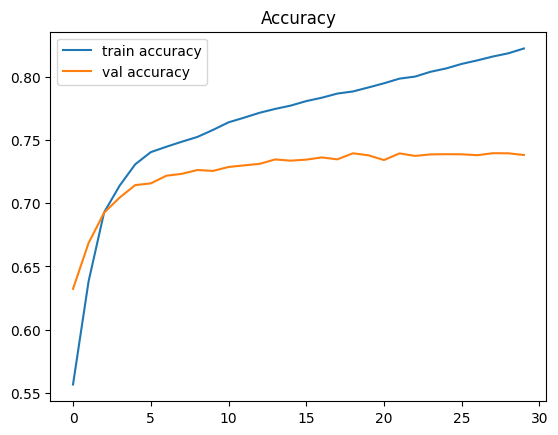

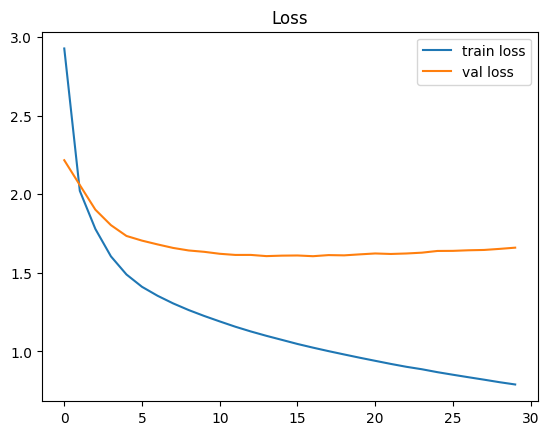

In [33]:
import json
import matplotlib.pyplot as plt

with open("train_history/history.json", "r") as f:
    history = json.load(f)

# Accuracy
plt.figure()
plt.plot(history["accuracy"], label="train accuracy")
plt.plot(history["val_accuracy"], label="val accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history["loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()
plt.show()

# 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

OBSERVACIÓN: DEBE HABER EJECUTADO LAS CELDAS ANTERIORES AL GRÁFICO PARA CLONAR EL REPOSITORIO

In [34]:
model = tf.keras.models.load_model("models/modelo_seq2seq.keras")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 9, 100)    │    187,800 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 10, 256)   │    477,952 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 256),     │    365,568 │ embedding_1[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 10, 256), │    525,312 │ embedding_2[0][0… │
│                     │ (None, 256),      │            │ lstm_1[0][1],     │
│                     │ (None, 256)]      │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 1867)  │    479,819 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,733,755 (21.87 MB)

 Trainable params: 1,848,651 (7.05 MB)

 Non-trainable params: 187,800 (733.59 KB)

 Optimizer params: 3,697,304 (14.10 MB)

In [38]:
with open("tokenizers/tokenizer_inputs.pkl", "rb") as f:
    tokenizer_inputs = pickle.load(f)

with open("tokenizers/tokenizer_outputs.pkl", "rb") as f:
    tokenizer_outputs = pickle.load(f)

input_vocab_size = len(tokenizer_inputs.word_index) + 1
output_vocab_size = len(tokenizer_outputs.word_index) + 1

## Construcción del Encoder

In [39]:
encoder_inputs = model.input[0]

encoder_embedding = model.layers[2](encoder_inputs)
encoder_lstm = model.layers[4]

_, state_h, state_c = encoder_lstm(encoder_embedding)

encoder_states = [state_h, state_c]

encoder_model = tf.keras.Model(encoder_inputs, encoder_states)

## Construcción del Decoder

In [40]:
decoder_inputs = model.input[1]

decoder_state_input_h = tf.keras.Input(shape=(model.layers[4].units,))
decoder_state_input_c = tf.keras.Input(shape=(model.layers[4].units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_embedding = model.layers[3](decoder_inputs)

decoder_lstm = model.layers[5]

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_embedding,
    initial_state=decoder_states_inputs
)

decoder_outputs = model.layers[6](decoder_outputs)

decoder_states = [state_h, state_c]

decoder_model = tf.keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states
)

## Inferencia del modelo

La siguiente función implementa el proceso de inferencia utilizando los modelos de encoder y decoder por separado.  
Primero, el encoder genera los estados internos a partir de la secuencia de entrada y luego el decoder produce la respuesta palabra por palabra hasta encontrar el token de fin (`<eos>`).

In [83]:
def decode_sequence(input_seq, temperature=0.7):

    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))

    target_seq[0, 0] = tokenizer_outputs.word_index["<sos>"]

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        preds = output_tokens[0, -1, :]

        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        sampled_token_index = np.random.choice(
            len(preds),
            p=preds
        )

        sampled_word = tokenizer_outputs.index_word.get(
            sampled_token_index, ""
        )

        if sampled_word == "<eos>" or len(decoded_sentence.split()) > 50:
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_word

        target_seq = np.array([[sampled_token_index]])

        states_value = [h, c]

    return decoded_sentence.strip()

## Pruebas de inferencia

A continuación se realizan distintas pruebas de inferencia utilizando frases de entrada de ejemplo.  
Cada oración es convertida a secuencia numérica y luego procesada por el modelo para generar una respuesta.

In [84]:
test_inputs = [
    "hola",
    "como estas",
    "que haces",
    "donde vives",
    "te gustan los videojuegos",
    "cual es tu nombre",
    "adios"
]

temperatures = [0.3, 0.7, 0.9]

for temp in temperatures:

    print("=" * 50)
    print(f"TEMPERATURE = {temp}")
    print("=" * 50)

    for sample_input in test_inputs:

        seq = tokenizer_inputs.texts_to_sequences([sample_input])

        seq = tf.keras.preprocessing.sequence.pad_sequences(
            seq,
            maxlen=9,
            padding="post"
        )

        response = decode_sequence(seq, temperature=temp)

        print(f"Entrada   : {sample_input}")
        print(f"Respuesta : {response}")
        print("-" * 40)

    print("\n")

TEMPERATURE = 0.3
Entrada   : hola
Respuesta : hello how are you today
----------------------------------------
Entrada   : como estas
Respuesta : i love to read
----------------------------------------
Entrada   : que haces
Respuesta : i love to read
----------------------------------------
Entrada   : donde vives
Respuesta : i love to read
----------------------------------------
Entrada   : te gustan los videojuegos
Respuesta : i love to read
----------------------------------------
Entrada   : cual es tu nombre
Respuesta : i love to read
----------------------------------------
Entrada   : adios
Respuesta : i love to read
----------------------------------------


TEMPERATURE = 0.7
Entrada   : hola
Respuesta : hi how are you today
----------------------------------------
Entrada   : como estas
Respuesta : i love to read
----------------------------------------
Entrada   : que haces
Respuesta : i love to read
----------------------------------------
Entrada   : donde vives
Respuesta

In [85]:
test_inputs = [
    "hello",
    "how are you",
    "what do you do",
    "where do you live",
    "do you like games",
    "what is your name",
    "goodbye"
]

temperatures = [0.3, 0.7, 0.9]

for temp in temperatures:

    print("=" * 50)
    print(f"TEMPERATURE = {temp}")
    print("=" * 50)

    for sample_input in test_inputs:

        seq = tokenizer_inputs.texts_to_sequences([sample_input])

        seq = tf.keras.preprocessing.sequence.pad_sequences(
            seq,
            maxlen=9,
            padding="post"
        )

        response = decode_sequence(seq, temperature=temp)

        print(f"Input    : {sample_input}")
        print(f"Response : {response}")
        print("-" * 40)

    print("\n")

TEMPERATURE = 0.3
Input    : hello
Response : hello how are you
----------------------------------------
Input    : how are you
Response : i am doing well how are you
----------------------------------------
Input    : what do you do
Response : i am a teacher i am a girl
----------------------------------------
Input    : where do you live
Response : i am a teacher i am a teacher
----------------------------------------
Input    : do you like games
Response : i like to go to the beach
----------------------------------------
Input    : what is your name
Response : i like to play video games
----------------------------------------
Input    : goodbye
Response : hello how are you today
----------------------------------------


TEMPERATURE = 0.7
Input    : hello
Response : hi how are you today
----------------------------------------
Input    : how are you
Response : i am doing well how are you
----------------------------------------
Input    : what do you do
Response : i am a teacher i

# Conclusiones

Se implementó correctamente el proceso de inferencia utilizando modelos separados de encoder y decoder, generando respuestas de manera autoregresiva token por token.

Durante las pruebas se evaluó el efecto de diferentes valores de temperatura (`0.3`, `0.7` y `0.9`) sobre la generación de texto. Se observó que:

- Con temperaturas bajas (`0.3`), el modelo produce respuestas más estables y repetitivas, tendiendo a seleccionar siempre las palabras con mayor probabilidad.
- Con temperaturas medias (`0.7`), las respuestas presentan una mayor diversidad manteniendo cierta coherencia.
- Con temperaturas altas (`0.9`), el modelo genera respuestas más variadas y creativas, aunque aparecen frases incoherentes o sin sentido semántico.

También,si bien la idea es traducir, se observó que el modelo responde considerablemente mejor cuando las entradas se encuentran en el mismo idioma utilizado durante el entrenamiento. Las pruebas en español mostraron respuestas repetitivas y baja comprensión semántica, mientras que las pruebas en inglés produjeron resultados más coherentes.

Finalmente, se concluye que la calidad de las respuestas depende fuertemente del tamaño y diversidad del dataset de entrenamiento. Debido a que el conjunto de datos utilizado es reducido, el modelo presenta limitaciones de generalización y tiende a repetir respuestas frecuentes aprendidas durante el entrenamiento.